# Alzheimer’s Disease Detection with InceptionV3 (GoogleNet v3)
Updated with comprehensive evaluation metrics.

In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, roc_auc_score

from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from matplotlib.colors import LogNorm


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


DATA_ROOT = "/kaggle/input/imagesoasis"
DATASET_DIR = "/kaggle/input/datasets/ninadaithal/imagesoasis/Data"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 3

CLASS_LABELS = ['Non Demented', 'Very Mild Dementia', 'Mild/Moderate Dementia']
LABEL_MAP = {
    'Non Demented': 0,
    'Very mild Dementia': 1,
    'Mild Dementia': 2,
    'Moderate Dementia': 2,
}
AUTOTUNE = tf.data.AUTOTUNE
print("Imports and configuration ready.")

2026-04-10 16:59:42.426727: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775840382.796666      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775840382.907326      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775840383.931469      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775840383.931511      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775840383.931514      55 computation_placer.cc:177] computation placer alr

Imports and configuration ready.


In [3]:
def get_info_from_filename(filename: str):
    pattern = re.compile(r'OAS1_(\d+)_MR(\d+)_mpr-(\d+)_(\d+)\.jpg$')
    match = pattern.match(filename)
    if match is None:
        return None
    patient_id, mr_id, scan_id, layer_id = match.groups()
    return int(patient_id), int(mr_id), int(scan_id), int(layer_id)

def create_ref_df(dataset_path: str) -> pd.DataFrame:
    paths, labels, patient_ids = [], [], []
    for folder in sorted(os.listdir(dataset_path)):
        folder_path = os.path.join(dataset_path, folder)
        if not os.path.isdir(folder_path): continue
        for file in sorted(os.listdir(folder_path)):
            parsed = get_info_from_filename(file)
            if parsed is None: continue
            patient_id, _, _, _ = parsed
            paths.append(os.path.join(folder_path, file))
            labels.append(folder)
            patient_ids.append(patient_id)
    return pd.DataFrame({'path': paths, 'label': labels, 'patient_id': patient_ids})

ref_df = create_ref_df(DATASET_DIR)
ref_df['label_int'] = ref_df['label'].map(LABEL_MAP)
ref_df = ref_df.dropna(subset=['label_int'])
ref_df['label_int'] = ref_df['label_int'].astype(int)
print("Shape:", ref_df.shape)

Shape: (86437, 4)


In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_val_idx, test_idx = next(gss.split(ref_df, groups=ref_df['patient_id']))
train_val_df = ref_df.iloc[train_val_idx]
test_df = ref_df.iloc[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['patient_id']))
train_df = train_val_df.iloc[train_idx]
val_df = train_val_df.iloc[val_idx]

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 50996, Val: 16897, Test: 18544


In [6]:
def load_and_preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    return img, label

def create_dataset(df, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((df['path'].values, df['label_int'].values))
    if is_training:
        ds = ds.shuffle(len(df), seed=SEED)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = create_dataset(train_df, is_training=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

In [7]:
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_int']),
    y=train_df['label_int']
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.4409282700421941), 1: np.float64(1.908675799086758), 2: np.float64(4.804597701149425)}


In [11]:
from tensorflow.keras import regularizers


data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False

model = models.Sequential([
    tf.keras.Input(shape=IMG_SIZE + (3,)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.5), # Increased from 0.3
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 2, 2, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,065,443 (84.17 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [12]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=3)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.4969 - loss: 3.2985 - val_accuracy: 0.6059 - val_loss: 2.1593 - learning_rate: 1.0000e-04
Epoch 2/20
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 69s 43ms/step - accuracy: 0.5962 - loss: 2.0570 - val_accuracy: 0.6047 - val_loss: 1.5640 - learning_rate: 1.0000e-04
Epoch 3/20
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.6099 - loss: 1.4992 - val_accuracy: 0.6093 - val_loss: 1.2211 - learning_rate: 1.0000e-04
Epoch 4/20
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.6182 - loss: 1.2122 - val_accuracy: 0.6025 - val_loss: 1.0899 - learning_rate: 1.0000e-04
Epoch 5/20
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.6272 - loss: 1.0906 - val_accuracy: 0.5610 - val_loss: 1.1072 - learning_rate: 1.0000e-04
Epoch 6/20
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.6339 - loss: 1.0261 - val_accuracy: 0.5866 - val_loss: 1.0032 - learning_rate: 1.0000e-04
Epoch 7/20
1594/1594 ━━━━━━━━━━━━━━━━━━━

## Evaluation Metrics & Visualizations

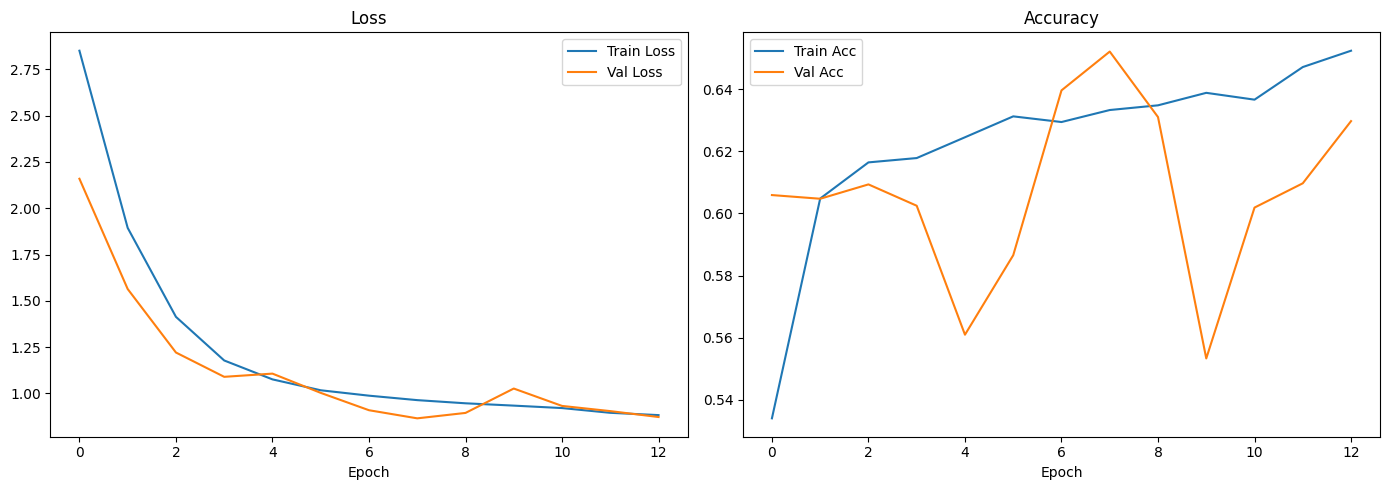

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

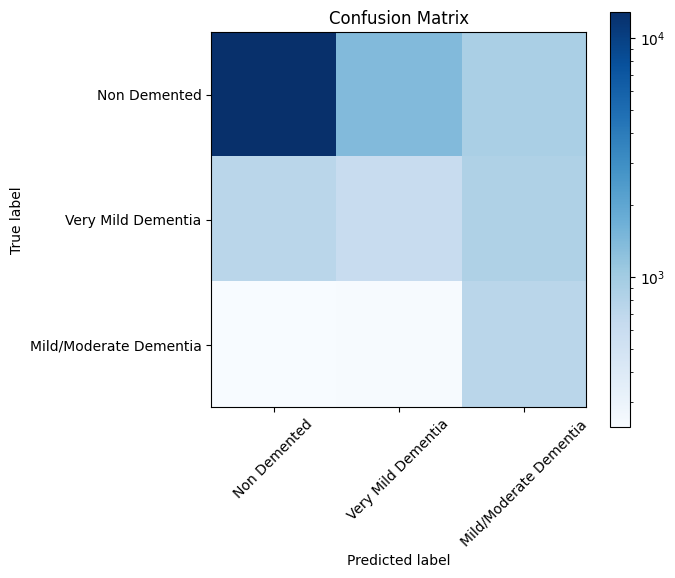

                        precision    recall  f1-score   support

          Non Demented     0.9296    0.8490    0.8875     15128
    Very Mild Dementia     0.2714    0.2741    0.2728      2196
Mild/Moderate Dementia     0.2971    0.6115    0.3999      1220

              accuracy                         0.7653     18544
             macro avg     0.4994    0.5782    0.5200     18544
          weighted avg     0.8101    0.7653    0.7826     18544



In [15]:
y_probs = model.predict(test_ds, verbose=0)
y_pred  = np.argmax(y_probs, axis=1)
y_test_int = test_df['label_int'].values

cm = confusion_matrix(y_test_int, y_pred, labels=[0, 1, 2])

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues, norm=LogNorm())
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, CLASS_LABELS, rotation=45)
plt.yticks(tick_marks, CLASS_LABELS)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

print(classification_report(y_test_int, y_pred, target_names=CLASS_LABELS, digits=4))

In [ ]:
model.save("alzheimers_inceptionv3_final.keras")
print("Model saved as alzheimers_inceptionv3_final.keras")

In [16]:
def scotts_pi(cm):
    total = np.sum(cm)
    if total == 0:
        return np.nan
    p_o = np.trace(cm) / total
    row_totals = np.sum(cm, axis=1) / total
    col_totals = np.sum(cm, axis=0) / total
    p_e = np.sum(row_totals * col_totals)
    if np.isclose(1 - p_e, 0):
        return np.nan
    return (p_o - p_e) / (1 - p_e)

print("Scott's Pi:", round(scotts_pi(cm), 4))

Scott's Pi: 0.3642


In [17]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_int, y_pred, average=None, labels=[0, 1, 2], zero_division=0
)

for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    print(f"Class {i} ({CLASS_LABELS[i]}): Precision={p:.4f}  Recall={r:.4f}  F1={f:.4f}")

micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
    y_test_int, y_pred, average='micro', zero_division=0
)
print(f"Micro-average: Precision={micro_p:.4f}  Recall={micro_r:.4f}  F1={micro_f1:.4f}")

Class 0 (Non Demented): Precision=0.9296  Recall=0.8490  F1=0.8875
Class 1 (Very Mild Dementia): Precision=0.2714  Recall=0.2741  F1=0.2728
Class 2 (Mild/Moderate Dementia): Precision=0.2971  Recall=0.6115  F1=0.3999
Micro-average: Precision=0.7653  Recall=0.7653  F1=0.7653


In [18]:
y_test_onehot = tf.keras.utils.to_categorical(y_test_int, num_classes=NUM_CLASSES)

try:
    roc_auc_per_class = roc_auc_score(y_test_onehot, y_probs, average=None)
    for i, auc_score in enumerate(np.atleast_1d(roc_auc_per_class)):
        print(f"Class {i} ({CLASS_LABELS[i]}): ROC AUC = {auc_score:.4f}")
    roc_auc_micro = roc_auc_score(y_test_onehot, y_probs, average='micro')
    print("Micro-average ROC AUC:", round(roc_auc_micro, 4))
except ValueError as e:
    print("ROC AUC could not be computed:", e)

Class 0 (Non Demented): ROC AUC = 0.8858
Class 1 (Very Mild Dementia): ROC AUC = 0.7730
Class 2 (Mild/Moderate Dementia): ROC AUC = 0.8908
Micro-average ROC AUC: 0.9216
